<a href="https://colab.research.google.com/github/Ammar-creator-cmd/DataVisualization/blob/main/DigitRecognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
mnist = tf.keras.datasets.mnist

In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train.shape

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


(60000, 28, 28)

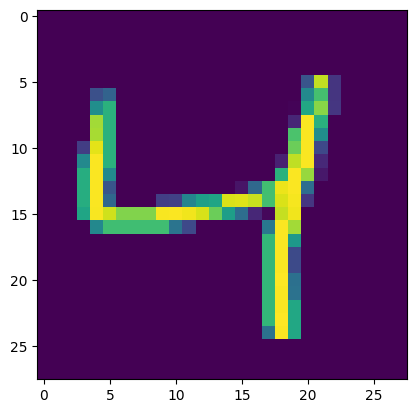

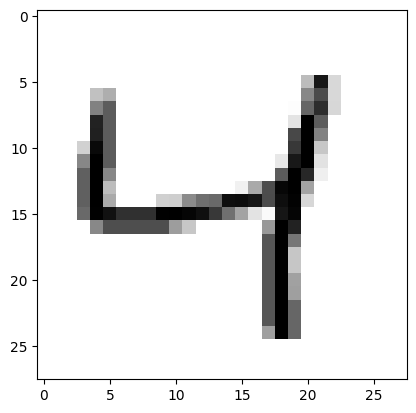

In [3]:
import matplotlib.pyplot as plt

plt.imshow(x_train[2])
plt.show()
plt.imshow(x_train[2], cmap = plt.cm.binary)

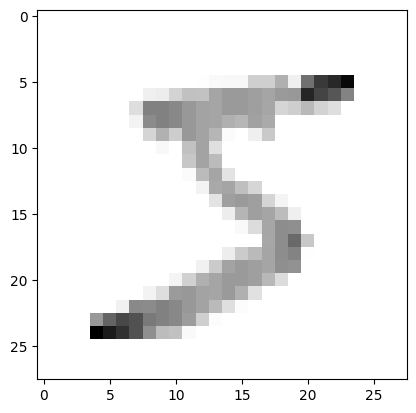

In [4]:
x_train = tf.keras.utils.normalize(x_train, axis =1)
x_test = tf.keras.utils.normalize(x_test, axis = 1)
plt.imshow(x_train[0], cmap = plt.cm.binary)

In [5]:
print(x_train[0])

[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.    

In [6]:
import numpy as np
img_size = 28
x_trainer = np.array(x_train).reshape(-1, img_size, img_size, 1)
x_tester = np.array(x_test).reshape(-1, img_size, img_size, 1)
print("Training shape", x_trainer.shape)
print("Testing shape", x_tester.shape)

Training shape (60000, 28, 28, 1)
Testing shape (10000, 28, 28, 1)


In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten, Conv2D, MaxPooling2D

model = Sequential()

model.add(Conv2D(32, (3, 3), activation = "relu", input_shape = x_trainer.shape[1:]))
#model.add(MaxPooling2D((2, 2)))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Conv2D = layer konvolusi 2D, dipakai untuk ekstraksi fitur dari gambar.
32 = jumlah filter (kernel) → model akan belajar 32 pola berbeda.
(3,3) = ukuran filter → tiap filter berukuran 3×3 piksel.
activation='relu' → fungsi aktivasi ReLU (Rectified Linear Unit), membuat jaringan lebih cepat belajar dan mengatasi masalah vanishing gradient.
input_shape=x_trainer.shape[1:] → bentuk input gambar, misalnya (28,28,1) (tinggi, lebar, channel).


In [8]:
model.add(Conv2D(64 , (3,3) , activation = 'relu'))
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))
# model.add(Conv2D(64 , (3,3) , activation = 'relu'))
# model.add(MaxPooling2D((2,2)))
model.add(Flatten())
model.add(Dense(256, activation = 'relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation = 'softmax'))

Bagian awal (Conv2D + Pooling) → ekstraksi fitur visual.
Dropout → mencegah overfitting.
Flatten + Dense → menggabungkan fitur dan melakukan klasifikasi.
Output Softmax → memberikan probabilitas untuk tiap kelas.

In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,359,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,380,938 (9.08 MB)

 Trainable params: 2,380,938 (9.08 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
#compile model that we have created for handwritten digit recognition project
model.compile(optimizer = "adam", loss = "sparse_categorical_crossentropy", metrics = ["accuracy"])

In [11]:
# fit x_trainer , y_train to the model to see accuracy of model:
model.fit(x_trainer,y_train, epochs = 5, validation_split = 0.3 , batch_size = 128,verbose=1)

Epoch 1/5
329/329 ━━━━━━━━━━━━━━━━━━━━ 80s 239ms/step - accuracy: 0.9172 - loss: 0.2776 - val_accuracy: 0.9690 - val_loss: 0.1019
Epoch 2/5
329/329 ━━━━━━━━━━━━━━━━━━━━ 74s 225ms/step - accuracy: 0.9727 - loss: 0.0899 - val_accuracy: 0.9818 - val_loss: 0.0591
Epoch 3/5
329/329 ━━━━━━━━━━━━━━━━━━━━ 85s 235ms/step - accuracy: 0.9810 - loss: 0.0621 - val_accuracy: 0.9844 - val_loss: 0.0528
Epoch 4/5
329/329 ━━━━━━━━━━━━━━━━━━━━ 74s 224ms/step - accuracy: 0.9845 - loss: 0.0488 - val_accuracy: 0.9856 - val_loss: 0.0473
Epoch 5/5
329/329 ━━━━━━━━━━━━━━━━━━━━ 82s 223ms/step - accuracy: 0.9869 - loss: 0.0405 - val_accuracy: 0.9865 - val_loss: 0.0448


In [12]:
test_loss, test_acc = model.evaluate(x_tester, y_test)
print("Test loss on 10,000 test samples", test_loss)
print("Validation Accuracy on 10,000 samples", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9883 - loss: 0.0366
Test loss on 10,000 test samples 0.0366213396191597
Validation Accuracy on 10,000 samples 0.9883000254631042


  9/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=('Tensor(shape=(32, 28, 28, 1))',)
  warnings.warn(msg)


313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step
6


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=('Tensor(shape=(None, 28, 28, 1))',)
  warnings.warn(msg)


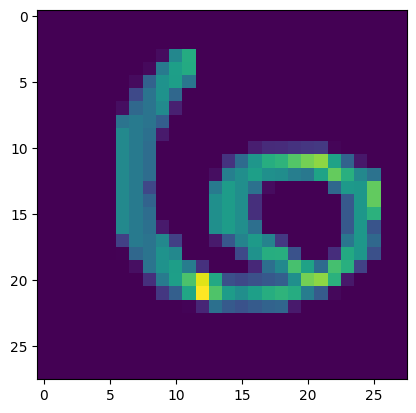

In [13]:
predictions = model.predict([x_tester])

print(np.argmax(predictions[54]))

plt.imshow(x_test[54])

In [14]:
model.save("digit_recogniser_model.h5")